Shape: (9994, 24)

Columns: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

================ KPI METRICS ================

Total Sales  : 2297200.86
Total Profit : 286397.02

================ TOP 5 CUSTOMERS ================

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


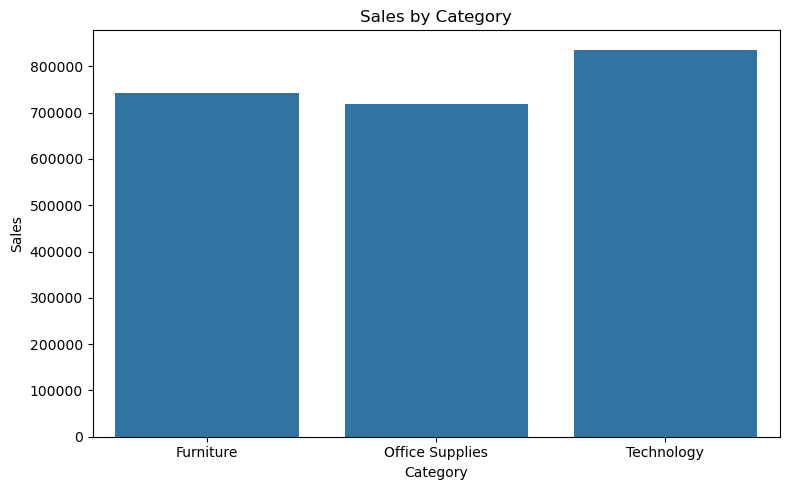

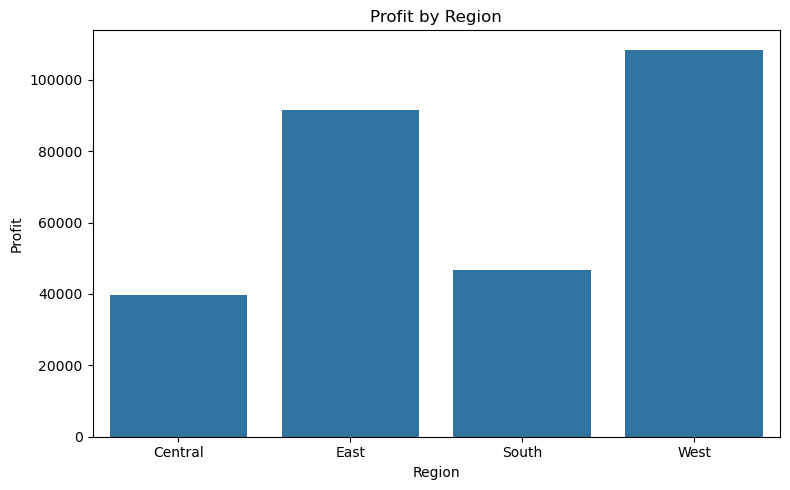

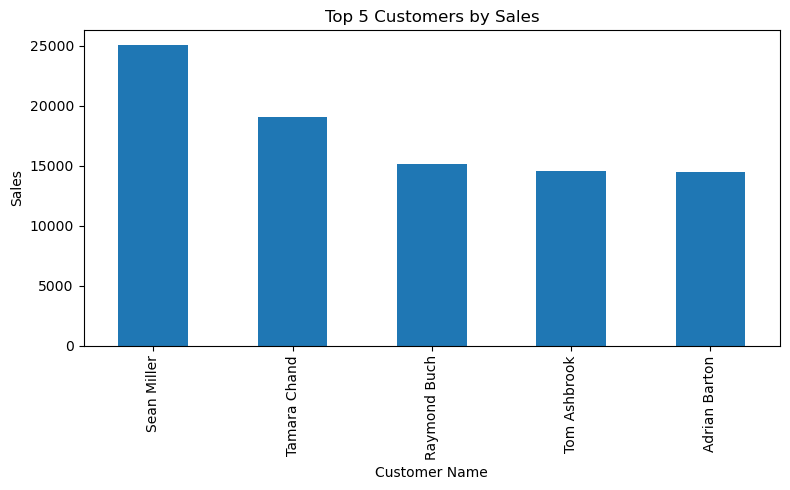

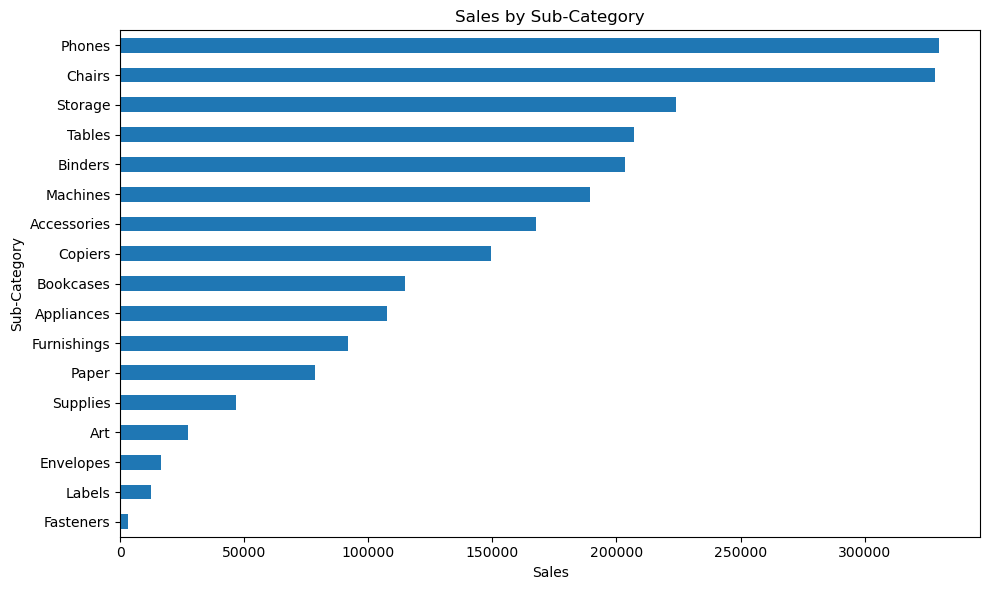


Dashboard Execution Completed Successfully


In [1]:

# ============================================================
# GLOBAL SUPERSTORE - JUPYTER DASHBOARD (FULL CODE)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix Jupyter plotting issue
%matplotlib inline

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(r"G:\Global_Superstore2.csv\Global_Superstore2.csv", encoding="latin1")

# Clean column names
df.columns = df.columns.str.strip()

# ============================================================
# 2. DATA CLEANING
# ============================================================

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True,
    errors='coerce'
)

df.dropna(inplace=True)

# ============================================================
# 3. BASIC FEATURE CHECK
# ============================================================

print("Shape:", df.shape)
print("\nColumns:", df.columns)

# ============================================================
# 4. SIMULATED FILTERS (JUPYTER VERSION)
# ============================================================

# You can change these manually like dashboard filters
selected_region = df['Region'].unique()
selected_category = df['Category'].unique()
selected_subcategory = df['Sub-Category'].unique()

filtered_df = df[
    (df['Region'].isin(selected_region)) &
    (df['Category'].isin(selected_category)) &
    (df['Sub-Category'].isin(selected_subcategory))
]

# ============================================================
# 5. KPIs
# ============================================================

total_sales = filtered_df['Sales'].sum()
total_profit = filtered_df['Profit'].sum()

print("\n================ KPI METRICS ================\n")
print("Total Sales  :", round(total_sales, 2))
print("Total Profit :", round(total_profit, 2))

# ============================================================
# 6. TOP 5 CUSTOMERS
# ============================================================

top_customers = (
    filtered_df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("\n================ TOP 5 CUSTOMERS ================\n")
print(top_customers)

# ============================================================
# 7. SALES BY CATEGORY
# ============================================================

category_sales = filtered_df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

# ============================================================
# 8. PROFIT BY REGION
# ============================================================

region_profit = filtered_df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=region_profit.index, y=region_profit.values)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

# ============================================================
# 9. TOP CUSTOMERS CHART
# ============================================================

plt.figure(figsize=(8,5))
top_customers.plot(kind='bar')
plt.title("Top 5 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

# ============================================================
# 10. SALES BY SUB-CATEGORY
# ============================================================

subcat_sales = filtered_df.groupby('Sub-Category')['Sales'].sum().sort_values()

plt.figure(figsize=(10,6))
subcat_sales.plot(kind='barh')
plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

# ============================================================
# DONE
# ============================================================
print("\nDashboard Execution Completed Successfully")